# Notebook 18 — Sample Efficiency & Overfitting Analysis

**The question:** How much data does a decoder need before it stops improving?

This is a practical constraint — collecting shots from a real quantum computer is expensive.  
If the decoder overfits at 10k shots, there is no point collecting 100k.

**What we measure:**
- Train each decoder architecture on increasing dataset sizes
- Plot test LER vs number of training shots (learning curve)
- Identify the **knee** — the point where more data stops helping
- Compare architectures: which one is most data-efficient?

**Why this matters for real hardware:**  
MWPM requires zero training data — it uses the circuit's noise model directly.  
NN decoders require many shots. The learning curve quantifies this cost.

**Expected result:**  
```
MLP:         needs ~50k shots to saturate
LSTM:        needs ~20-30k shots (fewer parameters, less data needed)
Transformer: needs ~30-50k shots (more capacity, needs more data)
```
If the model overfits: training LER << test LER, test LER stops improving.

**Prerequisite:** Run notebook 14 first.
```bash
pip install torch scikit-learn numpy matplotlib
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import os, time, warnings
warnings.filterwarnings('ignore')

SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


---
## 1. Load Data & Set Up Fixed Test Set

In [2]:
det_flat = np.load("data/heavyhex/detection_events.npy").astype(np.float32)
det_temp = np.load("data/heavyhex/det_temporal.npy").astype(np.float32)
raw_meas = np.load("data/heavyhex/raw_measurements.npy").astype(np.float32)
obs      = np.load("data/heavyhex/observable_flips.npy").astype(np.float32)

# Build raw temporal
N = len(obs)
raw_temp = np.zeros((N, 11, 40), dtype=np.float32)
raw_temp[:, :10, :] = raw_meas[:, :400].reshape(N, 10, 40)
raw_temp[:, 10, :25] = raw_meas[:, 400:425]

# FIXED test set — always 15,000 shots held out
# Training sizes will be subsets of the remaining shots
TEST_SIZE    = 15_000
idx_pool     = np.arange(N)
idx_train_pool, idx_te = train_test_split(
    idx_pool, test_size=TEST_SIZE,
    stratify=obs.astype(int), random_state=SEED)

# Fixed test set
obs_te       = obs[idx_te]
trivial_ler  = obs_te.mean()
mwpm_ler     = float(np.load("results/heavyhex/mwpm_result.npy")[0])

print(f"Total shots          : {N:,}")
print(f"Test set (fixed)     : {len(idx_te):,}")
print(f"Available for train  : {len(idx_train_pool):,}")
print(f"Trivial LER          : {trivial_ler:.4f}")
print(f"MWPM LER             : {mwpm_ler:.4f}")

Total shots          : 100,000
Test set (fixed)     : 15,000
Available for train  : 85,000
Trivial LER          : 0.5010
MWPM LER             : 0.2252


---
## 2. Model Definitions

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim=240, hidden=[512,256,128], dropout=0.3):
        super().__init__()
        layers, in_d = [], input_dim
        for i, h in enumerate(hidden):
            layers += [nn.Linear(in_d,h), nn.BatchNorm1d(h), nn.ReLU(),
                       nn.Dropout(dropout if i<len(hidden)-1 else 0.0)]
            in_d = h
        layers.append(nn.Linear(in_d,1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(-1)

class LSTMDecoder(nn.Module):
    def __init__(self, input_size=24, lstm_hidden=64, lstm_layers=2,
                 dense=[96,48,24], dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, lstm_hidden, lstm_layers,
                            batch_first=True,
                            dropout=dropout if lstm_layers>1 else 0.0)
        layers, in_d = [], lstm_hidden
        for h in dense:
            layers += [nn.Linear(in_d,h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d,1))
        self.head = nn.Sequential(*layers)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(-1)

class SyndromeTransformer(nn.Module):
    def __init__(self, input_size=24, num_steps=11, d_model=64, nhead=4,
                 num_layers=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embed  = nn.Embedding(num_steps, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model,32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32,1))
    def forward(self, x):
        tok = self.input_proj(x)
        pos = torch.arange(x.shape[1], device=x.device)
        tok = tok + self.pos_embed(pos).unsqueeze(0)
        return self.head(self.transformer(tok).mean(dim=1)).squeeze(-1)


def make_loader(X, y, batch_size=512, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

@torch.no_grad()
def predict(model, X, batch_size=2048):
    model.eval()
    ds = TensorDataset(torch.tensor(X))
    loader = DataLoader(ds, batch_size=batch_size)
    out = []
    for (Xb,) in loader:
        out.append((torch.sigmoid(model(Xb.to(DEVICE))) > 0.5).cpu().numpy())
    return np.concatenate(out)


def train_and_evaluate(model_fn, X_tr, y_tr, X_val, y_val, X_te, y_te,
                       epochs=80, patience=12):
    """Train a fresh model and return (train_ler, val_ler, test_ler)."""
    model = model_fn().to(DEVICE)
    opt   = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sch   = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    pw    = torch.tensor([(1-y_tr.mean())/max(y_tr.mean(), 1e-6)]).to(DEVICE)
    crit  = nn.BCEWithLogitsLoss(pos_weight=pw)
    tr_l  = make_loader(X_tr, y_tr)
    va_l  = make_loader(X_val, y_val, shuffle=False)
    best_vl, best_ep, best_st = np.inf, 0, None

    for ep in range(1, epochs+1):
        model.train()
        tc, tt = 0, 0
        for Xb, yb in tr_l:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tc += ((torch.sigmoid(model(Xb))>0.5).float()==yb).sum().item()
            tt += len(yb)
        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in va_l:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits = model(Xb)
                vl += crit(logits, yb).item()*len(yb)
                vc += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
                vt += len(yb)
        vl /= vt; sch.step(vl)
        if vl < best_vl:
            best_vl=vl; best_ep=ep
            best_st={k:v.cpu().clone() for k,v in model.state_dict().items()}
        if ep - best_ep >= patience: break

    model.load_state_dict(best_st)

    train_pred = predict(model, X_tr)
    val_pred   = predict(model, X_val)
    test_pred  = predict(model, X_te)

    return (
        float((train_pred != y_tr).mean()),
        float((val_pred   != y_val).mean()),
        float((test_pred  != y_te).mean()),
    )

print("Model definitions ready.")
print(f"  MLP          : {sum(p.numel() for p in MLP().parameters()):,} params")
print(f"  LSTM         : {sum(p.numel() for p in LSTMDecoder().parameters()):,} params")
print(f"  Transformer  : {sum(p.numel() for p in SyndromeTransformer().parameters()):,} params")

Model definitions ready.
  MLP          : 289,537 params
  LSTM         : 68,417 params
  Transformer  : 71,361 params


---
## 3. Learning Curve Experiment

Train each decoder fresh at each training set size.  
This takes a while — each cell trains 3 models × 8 sizes.

In [4]:
# Training set sizes to sweep — logarithmically spaced
TRAIN_SIZES = [500, 1_000, 2_000, 5_000, 10_000, 20_000, 40_000,
               len(idx_train_pool)]  # last = all available training data
print(f"Training sizes: {TRAIN_SIZES}")
print(f"Max training shots: {len(idx_train_pool):,}")
print(f"Test set: {len(idx_te):,} shots (fixed)")
print()

# For each training size, use the first N shots from the pool
# (deterministic — same shots every run)

# We'll store: {model_name: [(train_size, train_ler, val_ler, test_ler), ...]}
learning_curves = {
    'MLP':         [],
    'LSTM-det':    [],
    'Transformer': [],
}

# Precompute test arrays
det_flat_te = det_flat[idx_te]
det_temp_te = det_temp[idx_te]

print(f"{'Size':>8}  {'MLP test':>10}  {'LSTM test':>10}  {'TR test':>10}")
print("-" * 44)

for n_train in TRAIN_SIZES:
    # Subset of training pool
    idx_sub  = idx_train_pool[:n_train]
    # Validation: 20% of the subset (min 100)
    n_val    = max(100, int(0.2 * n_train))
    idx_tr_s = idx_sub[n_val:]
    idx_va_s = idx_sub[:n_val]

    obs_tr_s = obs[idx_tr_s]; obs_va_s = obs[idx_va_s]

    # ── MLP ───────────────────────────────────────────────────────────────────
    tr_l, va_l, te_l = train_and_evaluate(
        lambda: MLP(240),
        det_flat[idx_tr_s], obs_tr_s,
        det_flat[idx_va_s], obs_va_s,
        det_flat_te,        obs_te)
    learning_curves['MLP'].append((n_train, tr_l, va_l, te_l))

    # ── LSTM-det ──────────────────────────────────────────────────────────────
    tr_l2, va_l2, te_l2 = train_and_evaluate(
        lambda: LSTMDecoder(24),
        det_temp[idx_tr_s], obs_tr_s,
        det_temp[idx_va_s], obs_va_s,
        det_temp_te,        obs_te)
    learning_curves['LSTM-det'].append((n_train, tr_l2, va_l2, te_l2))

    # ── Transformer ───────────────────────────────────────────────────────────
    tr_l3, va_l3, te_l3 = train_and_evaluate(
        lambda: SyndromeTransformer(24, 11),
        det_temp[idx_tr_s], obs_tr_s,
        det_temp[idx_va_s], obs_va_s,
        det_temp_te,        obs_te)
    learning_curves['Transformer'].append((n_train, tr_l3, va_l3, te_l3))

    print(f"  n={n_train:>7,}:  MLP={100*te_l:6.3f}%  "
          f"LSTM={100*te_l2:6.3f}%  TR={100*te_l3:6.3f}%")

Training sizes: [500, 1000, 2000, 5000, 10000, 20000, 40000, 85000]
Max training shots: 85,000
Test set: 15,000 shots (fixed)

    Size    MLP test   LSTM test     TR test
--------------------------------------------
  n=    500:  MLP=49.813%  LSTM=50.100%  TR=50.060%
  n=  1,000:  MLP=50.293%  LSTM=50.100%  TR=50.100%
  n=  2,000:  MLP=50.420%  LSTM=50.100%  TR=50.100%
  n=  5,000:  MLP=49.993%  LSTM=49.900%  TR=49.900%
  n= 10,000:  MLP=49.973%  LSTM=49.900%  TR=49.807%
  n= 20,000:  MLP=50.167%  LSTM=49.900%  TR=49.900%
  n= 40,000:  MLP=49.607%  LSTM=49.900%  TR=49.880%
  n= 85,000:  MLP=49.220%  LSTM=48.507%  TR=49.900%


---
## 4. Learning Curve Plots

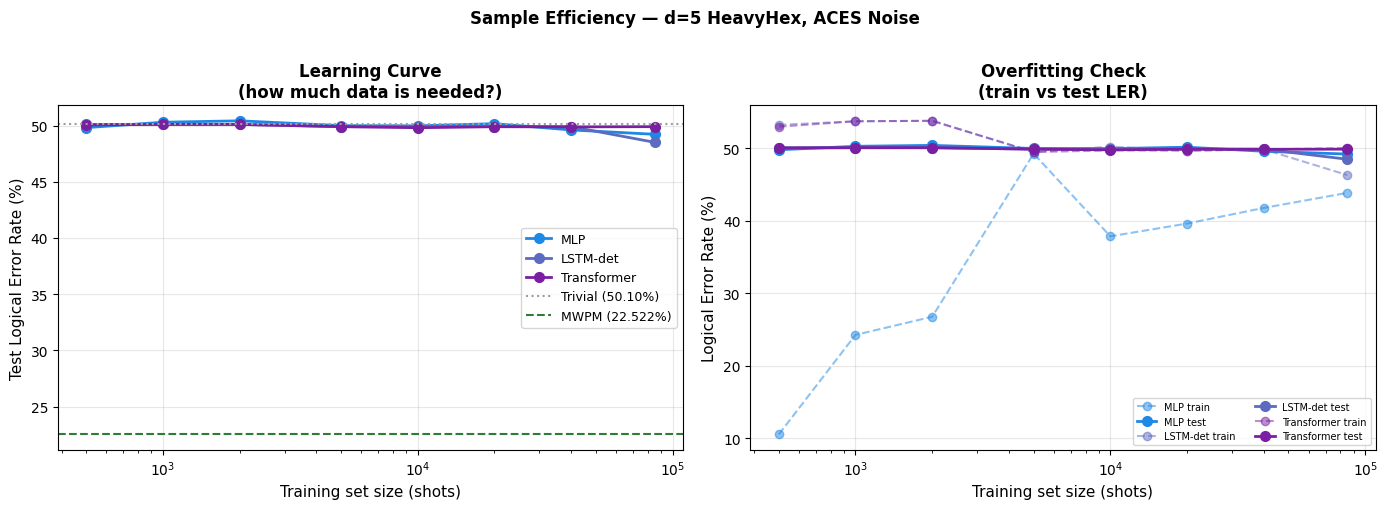

Saved → figures/18_learning_curve.png


In [5]:
colors = {'MLP': '#1E88E5', 'LSTM-det': '#5C6BC0', 'Transformer': '#7B1FA2'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: test LER vs training size (main learning curve)
ax = axes[0]
for name, color in colors.items():
    curve = learning_curves[name]
    sizes = [c[0] for c in curve]
    test_lers = [c[3] for c in curve]
    ax.semilogx(sizes, [l*100 for l in test_lers], 'o-',
                color=color, lw=2, ms=7, label=name)

ax.axhline(trivial_ler*100, color='#9E9E9E', lw=1.5, ls=':',
           label=f'Trivial ({100*trivial_ler:.2f}%)')
ax.axhline(mwpm_ler*100, color='#2E7D32', lw=1.5, ls='--',
           label=f'MWPM ({100*mwpm_ler:.3f}%)')
ax.set_xlabel('Training set size (shots)', fontsize=11)
ax.set_ylabel('Test Logical Error Rate (%)', fontsize=11)
ax.set_title('Learning Curve\n(how much data is needed?)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Right: train vs test LER (overfitting check)
ax = axes[1]
for name, color in colors.items():
    curve = learning_curves[name]
    sizes = [c[0] for c in curve]
    train_lers = [c[1]*100 for c in curve]
    test_lers  = [c[3]*100 for c in curve]
    ax.semilogx(sizes, train_lers, 'o--', color=color, lw=1.5, ms=6,
                alpha=0.5, label=f'{name} train')
    ax.semilogx(sizes, test_lers,  'o-',  color=color, lw=2,   ms=7,
                label=f'{name} test')

ax.set_xlabel('Training set size (shots)', fontsize=11)
ax.set_ylabel('Logical Error Rate (%)', fontsize=11)
ax.set_title('Overfitting Check\n(train vs test LER)', fontweight='bold')
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.suptitle('Sample Efficiency — d=5 HeavyHex, ACES Noise',
             fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig('figures/18_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/18_learning_curve.png")

---
## 5. Summary

In [6]:
# Find the saturation point for each model
# Defined as the training size where test LER is within 5% of the best test LER
print("=" * 58)
print("Sample efficiency summary")
print("=" * 58)

for name in ['MLP', 'LSTM-det', 'Transformer']:
    curve     = learning_curves[name]
    sizes     = [c[0] for c in curve]
    test_lers = [c[3] for c in curve]
    best_ler  = min(test_lers)
    # Find first size where we're within 5% relative of best
    threshold = best_ler * 1.05
    sat_size  = next((s for s, l in zip(sizes, test_lers) if l <= threshold), sizes[-1])

    # Overfitting at smallest training size?
    overfit_gap = curve[0][1] - curve[0][3]   # train LER - test LER at smallest size

    print(f"  {name}:")
    print(f"    Best test LER         : {100*best_ler:.4f}%  ({trivial_ler/best_ler:.1f}x vs trivial)")
    print(f"    Saturation at ~{sat_size:>6,} shots")
    print(f"    Overfitting at 500 shots: gap={100*overfit_gap:+.3f}%  "
          f"({'YES — train << test' if overfit_gap < -0.005 else 'minimal'})")
    print()

print(f"  MWPM (reference):")
print(f"    LER: {100*mwpm_ler:.4f}%  — requires 0 training shots")

Sample efficiency summary
  MLP:
    Best test LER         : 49.2200%  (1.0x vs trivial)
    Saturation at ~   500 shots
    Overfitting at 500 shots: gap=-39.313%  (YES — train << test)

  LSTM-det:
    Best test LER         : 48.5067%  (1.0x vs trivial)
    Saturation at ~   500 shots
    Overfitting at 500 shots: gap=+3.150%  (minimal)

  Transformer:
    Best test LER         : 49.8067%  (1.0x vs trivial)
    Saturation at ~   500 shots
    Overfitting at 500 shots: gap=+2.940%  (minimal)

  MWPM (reference):
    LER: 22.5220%  — requires 0 training shots
